# Task 1: Data Loading and Initial Inspection

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
url="https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df=pd.read_csv(url)

In [3]:
# Display the first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Check the data types of all columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
# Get descriptive statistics of the numerical columns
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
# Identify the total number of missing values for each column.
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Task 2: Univariate Analysis

In [7]:
# Calculate the overall survival rate (percentage of passengers who survived).
df['Survived'].mean() * 100

np.float64(38.38383838383838)

<Axes: xlabel='Survived', ylabel='count'>

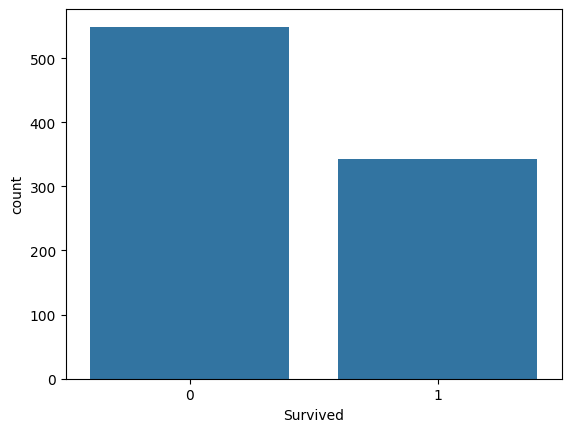

In [8]:
# Visualize the distribution of the Survived variable(count plot)
sns.countplot(x='Survived',data=df)

<Axes: xlabel='Pclass', ylabel='count'>

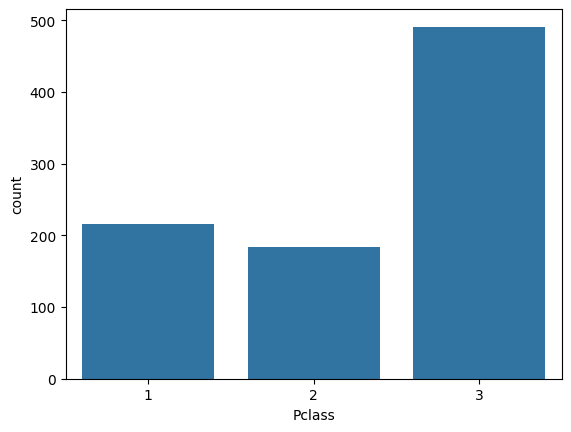

In [9]:
# Visualize the distribution of Pclass using a count plot.
sns.countplot(x='Pclass',data=df)

# Task 3: Bivariate and Multivariate Analysis

In [10]:
# Create a crosstabulation (or a grouped count) to show the count of survivors and non-survivors grouped by Sex.
df[['Sex','Survived']].groupby('Sex').value_counts()

Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

<Axes: xlabel='Sex', ylabel='count'>

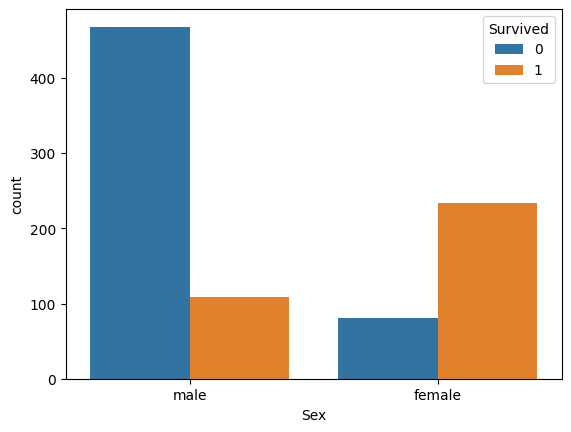

In [11]:
# Visualize this relationship using a stacked bar chart or a grouped count plot.
sns.countplot(x='Sex', hue='Survived', data=df)

## Question: Which gender had a significantly higher survival rate?
## Ans: Female

In [12]:
# Calculate and visualize the survival rate for each Pclass.
df[['Pclass','Survived']].groupby('Pclass').mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


<Axes: xlabel='Pclass', ylabel='Survived'>

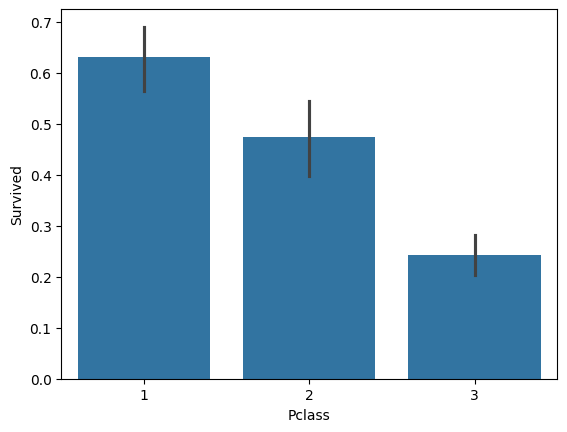

In [13]:
sns.barplot(x='Pclass', y='Survived', data=df)

## Question: Is there a clear correlation between ticket class and survival probability?
## Ans: Yes.Higher class indicates a higher probability of survival.

<Axes: xlabel='Survived', ylabel='Age'>

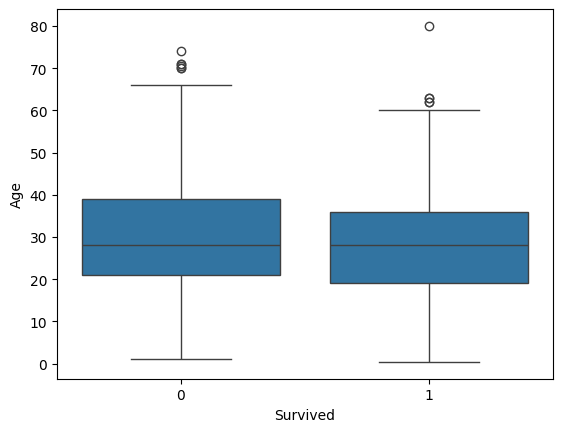

In [14]:
# Plot and compare the age distribution of survivors vs. non-survivors.
sns.boxplot(x="Survived", y="Age", data=df)

## Observation: What does the plot suggest about the survival chances of children and the elderly?
### Ans: The box plot shows that passengers who survived tend to have a lower median age compared to those who did not survive. There is a noticeable concentration of younger passengers (children) in the survived group, indicating that they had a higher chance of survival. In contrast, older passengers (elderly) appear more frequently in the non-survived group, suggesting they had a lower survival probability. Overall, the plot indicates that younger individuals were more likely to survive than older ones.

In [15]:
# Calculate and visualize the survival rate for each Embarked port.
df[['Embarked','Survived']].groupby('Embarked').mean()

,Survived
Embarked,
C,0.553571
Q,0.389610
S,0.336957


<Axes: xlabel='Embarked', ylabel='count'>

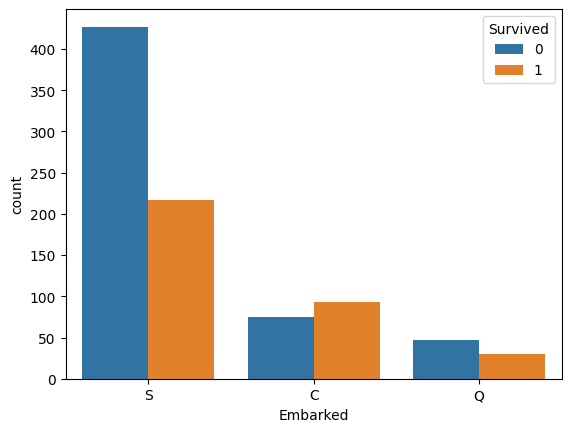

In [16]:
sns.countplot(x='Embarked', hue='Survived', data=df)

# Task 4: Conclusion and Insights

## The EDA shows that Sex, Passenger Class (Pclass), and Age were the most significant factors affecting survival on the Titanic. Female passengers had a much higher survival rate compared to males. Passengers in higher classes specially Pclass 1 were more likely to survive than those in lower classes. Additionally, younger passengers, particularly children, had better chances of survival than older individuals. Therefore, Sex, Pclass, and Age are the strongest predictors of survival in this dataset.